# You can run sapphire interactively in 3 simple steps:
1. import sapphire
2. define python dictionary of input parameters (see docs and below) 
3. sapphire.run(parameters) 

Soon there will be:
- a way to run from the command line "python -m sapphire parameters.json"-
- repeatedly run internally with built-in HMC/nested sampling functions
- the JAX version ported over for JIT (10x speed boost) and gradients (for both optimization and physical interpretation)

In [17]:
%matplotlib inline
import sys
sys.path.insert(0, '/mnt/ceph/users/skoudmani/JAXProj/sapphire/sapphire/')
import numpy as np
import matplotlib.pyplot as plt
from timeit import default_timer as timer
import pandas as pd
from astropy.table import Table
from astropy.cosmology import Planck15

import importlib

import sapphire 

importlib.reload(sapphire)

<module 'sapphire' from '/mnt/ceph/users/skoudmani/JAXProj/sapphire/sapphire/__init__.py'>

In [18]:
""" This is an optional feature we are using to downsample the # of halos we will model to speed up computation time """

# define a list of (Mlow,Mhigh,N) tuples with same bin definitions as Behroozi+19 relation
# we will only model N random halos within each of these z=0 Mvir mass bins to cut down on modeling time
# this list of tuples is an input runtime parameter for sapphire below (along with np.random.seed(#) for reproducibility) 
downsample_bins = np.arange(10.0,14.2,0.2) # note the masses are log10 mvir
print(downsample_bins)

# we will ask for 5 random halos per mass bin
downsample_defs = [(downsample_bins[i],downsample_bins[i+1],5) for i in range(len(downsample_bins)-1)]

downsample_defs

[10.  10.2 10.4 10.6 10.8 11.  11.2 11.4 11.6 11.8 12.  12.2 12.4 12.6
 12.8 13.  13.2 13.4 13.6 13.8 14. ]


[(10.0, 10.2, 5),
 (10.2, 10.399999999999999, 5),
 (10.399999999999999, 10.599999999999998, 5),
 (10.599999999999998, 10.799999999999997, 5),
 (10.799999999999997, 10.999999999999996, 5),
 (10.999999999999996, 11.199999999999996, 5),
 (11.199999999999996, 11.399999999999995, 5),
 (11.399999999999995, 11.599999999999994, 5),
 (11.599999999999994, 11.799999999999994, 5),
 (11.799999999999994, 11.999999999999993, 5),
 (11.999999999999993, 12.199999999999992, 5),
 (12.199999999999992, 12.399999999999991, 5),
 (12.399999999999991, 12.59999999999999, 5),
 (12.59999999999999, 12.79999999999999, 5),
 (12.79999999999999, 12.99999999999999, 5),
 (12.99999999999999, 13.199999999999989, 5),
 (13.199999999999989, 13.399999999999988, 5),
 (13.399999999999988, 13.599999999999987, 5),
 (13.599999999999987, 13.799999999999986, 5),
 (13.799999999999986, 13.999999999999986, 5)]

In [19]:
# set up a general parameters dict 

# try running new thermal_general model on same 656 TNG trees 
parameters = {'output_path':'/mnt/ceph/users/skoudmani/JAXProj/outputs/', # path where any output files should be saved (irrelevant if return_or_write=='return' below)
              
              ### runtime-related related parameters (you only need to vary tree_path) 
              
              'tree_type':'tng_sapphire', # type of merger trees / MAHs -- this determines what read_trees module gets loaded
              'tree_path':'/mnt/ceph/users/skoudmani/JAXProj/sapphire/data/tng_trees_compactified_20subvolumes.npz', # either a directory containing tree files or path to single tree file itself 
              'halo_names':[], # optional for certain simulations -- list of halo names/IDs to process (default=empty=process all trees for given tree_type and tree_dir)
              'subvolumes':None, # for testing speed purposes, only work with trees from a single TNG subvolume 
              'num_readers':5, # irrelevant for tree_type='tng_sapphire'
              'num_writers':5, # irrelevant when return_or_write = 'return' (otherwise how many output writer tasks to start in parallel)
              'return_or_write':'return', # if 'return', return pandas dataframe (you should assign to a variable below); if 'write' then save dataframe to hdf5
              'min_root_mass':1e10, # relevant for tree_type ='tng' and 'tng_sapphire', not 'fire2' or 'fire2_pandya22'
              'max_root_mass':None, # relevant for tree_type=tng_sapphire -- halos above this z=0 Mvir will not be modeled (set to None or 0 to model everything)
              'downsample_defs':downsample_defs, # list of tuples (logMlow,logMhigh,N) such that N random halos will be chosen in each mass bin (None otherwise)
              'downsample_seed':999, # np.random.seed(#) to ensure reproducibility when downsampling to N random halos in each mass bin (None otherwise)
              'rtol':1e-5, # relative error tolerance for ODE solver (this controls error on exponent of state variables), should be 1e-3 or lower 
              'atol':1e-3, # absolute error tolerance for ODE solver (this controls early evolution when ICs close to 0), should be 1e-3 or lower 
              
              ### fixed physical model parameters (this just sets the overall physical model and associated fixed parameters) 
              
              'physical_model':'thermal_general', # name of physical model (and associated free parameter functional forms)
              'coolfunc':'wiersma09', # which cooling function to use (wiersma09, sd93, ploeckinger20)
              'alpha_n':-3/2., # slope of CGM density power law
              'alpha_T':0.0, # slope of CGM temperature power law 
              'tau_escape':1.0, # scales the halo outflow timescale tdyn=tau*Rvir/Vvir
              'f_recycle':0.4, # instantaneous stellar-->ISM recycling fraction 
              'e_wind_halo':1.0, # specific energy of halo wind relative to Ecgm/Mcgm                            
              'yZ':0.02, # metal yield of 1 SN per 100 Msun of stars formed (2 Msun / 100 Msun = 0.02 for 10 Msun of SN ejecta)
              'return_all':False, # whether to return only the ODE RHS for solver, or all properties at each time for outputting
              
              ### FREE PARAMETERS BELOW THIS LINE -- WE WILL VARY A SUBSET OF THESE 
              ### there are 4 physical parameters: mass, energy and metal loading factors, and the ISM depletion time
              ### each physical parameter has 4 hyperparameters describing a power law: normalization, slope, and the redshift dependences of those two
              ### the exact power law is X(Vvir,z) = A * (Vvir/125.)**(alpha0 + alphaz*(1+z)) * (1+z)**beta              
              
              'etaM_A':0.1, # normalization of power law for mass loading factor [prior range: 0.01 to 100]
              'etaM_alpha0':-0.5, # slope of power law for mass loading factor [prior range: -2 to 2]
              'etaM_alphaz':0.0, # this can be fixed to 0; redshift dependence of slope of power law for mass loading factor [prior range: -2 to 2]
              'etaM_beta':0.0, # this can be fixed to 0; redshift dependence of normalization of power law for mass loading factor [prior range: -2 to 2]
              'tdep_A':3.0, # [prior range: 0.01 to 10]
              'tdep_alpha0':-3.0, # [prior range: -2 to 2]
              'tdep_alphaz':0.0, # this can be fixed to 0 [prior range: -2 to 2]
              'tdep_beta':-0.7, # [prior range: -2 to 2]
              'etaE_A':0.5, # [prior range: 0.01 to 1]
              'etaE_alpha0':-0.5, # [prior range: -2 to 2]
              'etaE_alphaz':0.0, # this can be fixed to 0 [prior range: -2 to 2]
              'etaE_beta':0.0,   # this can be fixed to 0 [prior range: -2 to 2]
              'etaZ_A':0.5, # [prior range: 0.01 to 1]
              'etaZ_alpha0':0.0, # [prior range: -2 to 2]
              'etaZ_alphaz':0.0, # this can be fixed to 0 [prior range: -2 to 2]
              'etaZ_beta':0.0} # this can be fixed to 0 [prior range: -2 to 2]



In [20]:
tstart = timer()
df_results = sapphire.run(parameters) # this is the only line you need, I just enclosed it in a timer for benchmarking
print('Finished in %s sec'%(timer()-tstart))


Finished in 61.24140127600003 sec


In [21]:
### the results are returned as a pandas dataframe 
# the row index is roothaloid and the columns are different physical properties 
# the entries are the time series of these physical properties for each halo 
df_results

,tcool_eff,Ebind_cgm,f_prev,MZdot_cgm,tdyn_halo,Edot_in_halo,MZ_ism,Vvir,Edot_out_halo,f_UV,...,t_accrete,M_ism,tdep_ism,MZdot_star,Rvir,sol_nfev,sol_njev,sol_nlu,sol_success,sol_status
1123826638,"[inf, inf, inf, inf, inf, inf, inf, inf, inf, ...","[3.7334515810312286e+53, 3.756355310111697e+53...","[0.2796857614537957, 0.27973810817904615, 0.27...","[5.7334823629373135, 5.6730761047292875, 5.614...","[0.08592894755215293, 0.08605548137559095, 0.0...","[3.6538497820609237e+37, 3.662088566833824e+37...","[2.0000000000000003e-06, 2.30059643479206e-06,...","[27.396714754287732, 27.41297310557957, 27.429...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.999863140689785, 0.9998574601542979, 0.9998...",...,"[inf, inf, inf, inf, inf, inf, inf, inf, inf, ...","[1.0, 0.9999755406429026, 0.9999509959127822, ...","[53.196650203366296, 53.185624479120015, 53.17...","[0.005331938606768886, 0.006155223676620106, 0...","[2.4076391824591843, 2.4126154250661567, 2.417...","[1071.0, 1071.0, 1071.0, 1071.0, 1071.0, 1071....","[63.0, 63.0, 63.0, 63.0, 63.0, 63.0, 63.0, 63....","[223.0, 223.0, 223.0, 223.0, 223.0, 223.0, 223...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1123011124,"[inf, inf, inf, inf, inf, inf, inf, inf, inf, ...","[8.939156627584784e+53, 8.972816488376608e+53,...","[0.3058678244345181, 0.3059229361936951, 0.305...","[4.310585033359077, 4.277471367507032, 4.24512...","[0.06964118079227428, 0.06974275198262833, 0.0...","[6.501735603642653e+37, 6.508454074145549e+37,...","[2.0000000000000003e-06, 2.5410113769804623e-0...","[34.02439142884166, 34.0361394769291, 34.04792...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.9999982561577893, 0.9999981747534815, 0.999...",...,"[inf, inf, inf, inf, inf, inf, inf, inf, inf, ...","[1.0, 0.9999571645401137, 0.999914204997175, 0...","[24.727579148750053, 24.743690591416467, 24.75...","[0.008938425607993994, 0.0113897410367946, 0.0...","[2.4233152425471207, 2.4276875816266776, 2.432...","[1077.0, 1077.0, 1077.0, 1077.0, 1077.0, 1077....","[61.0, 61.0, 61.0, 61.0, 61.0, 61.0, 61.0, 61....","[193.0, 193.0, 193.0, 193.0, 193.0, 193.0, 193...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1124729141,"[inf, 0.7761683428430896, 0.09029245169647358,...","[5.193521929083939e+53, 5.2369748461974445e+53...","[0.27839911199003203, 0.2784588938131775, 0.27...","[13.100515789249668, 11.819252940488123, 7.927...","[0.12878311142312965, 0.12895308318483872, 0.1...","[5.339986244713643e+37, 5.348336008453316e+37,...","[2.0000000000000003e-06, 0.003488917379625302,...","[26.99136779546184, 27.01045152255384, 27.0295...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.995551587144687, 0.9955267021372582, 0.9955...",...,"[inf, 0.8253859495210826, 0.13959562878579396,...","[1.0, 1689.2449738146454, 654348.7624411518, 1...","[68.10119362716256, 68.05026215938535, 67.9991...","[0.006428937866456308, 11.25294791769473, 665....","[3.5549805461639523, 3.562189312633976, 3.5694...","[1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000....","[57.0, 57.0, 57.0, 57.0, 57.0, 57.0, 57.0, 57....","[211.0, 211.0, 211.0, 211.0, 211.0, 211.0, 211...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1124728969,"[inf, inf, inf, inf, inf, inf, inf, inf, inf, ...","[2.480020827022071e+53, 2.484495168628152e+53,...","[0.27482706344027014, 0.2748312169262637, 0.27...","[1.4840337843734486, 1.4864566643722605, 1.488...","[0.07703643868941358, 0.07714975824394009, 0.0...","[9.106143750496116e+36, 9.108796414588504e+36,...","[2.0000000000000003e-06, 2.2432134027838368e-0...","[25.802162612454655, 25.8036057985101, 25.8050...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.9999593545516584, 0.9999574553359306, 0.999...",...,"[inf, inf, inf, inf, inf, inf, inf, inf, inf, ...","[1.0, 0.9999800526878125, 0.9999600651392098, ...","[59.98787

In [22]:
# suppose the only thing we cared about was predicting the z=0 SMHM relation for a given set of model parameters

# use list comprehension to store final z=0 Mvir and Mstar of each halo (i.e., of each row aka roothaloid of df_filtered)
# here we are iterating over each row which is a distinct roothaloid
# the values of every column for a given row/roothaloid are numpy arrays of time series of that property going from high-z to z~0

z0_Mvir = np.array([df_results.iloc[irow]['Mvir'][-1] for irow in range(len(df_results))])
z0_Mstar = np.array([df_results.iloc[irow]['M_star'][-1] for irow in range(len(df_results))])

Text(0, 0.5, '$\\log_{10}M_{\\rm star}/M_{\\rm vir}$ (z=0)')

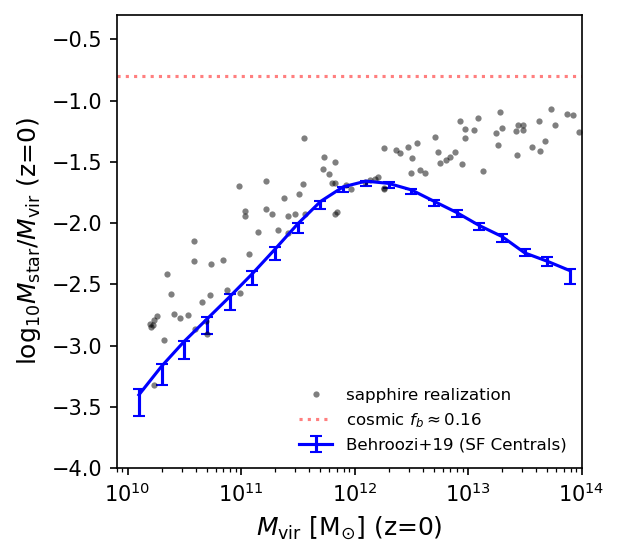

In [23]:
# overplot the z=0 SMHM relation of this model vs the Behroozi SMHM relation for centrals at z=0

fig, ax = plt.subplots(1,figsize=(4,4),dpi=150)

### plot Behroozi+19 relation including only central SF galaxies/halos
# first read in Behroozi+19 UniverseMachine DR1 Median SMHM relation at z=0  
# and discard bins below logmvir<10.5 due to Bolshoi-Planck resolution limit (not sure why he included these)
tum = Table.read('smhm_a1.002312.dat',format='ascii')
tum = tum[(tum['HM(0)']>=10.0) & (tum['HM(0)']<=14.0)]

ax.errorbar(10**tum['HM(0)'],tum['Med_Cen_SF(7)'],yerr=[np.abs(tum['Err-(9)']),np.abs(tum['Err+(8)'])],fmt='b-',capsize=3,label='Behroozi+19 (SF Centrals)')

# plot our model's realization
ax.plot(z0_Mvir,np.log10(z0_Mstar/z0_Mvir),'k.',alpha=0.5,mec='none',label='sapphire realization')

ax.set_xscale('log')
ax.set_xlim(None,1e14)
ax.set_ylim(-4,-0.3)

ax.axhline(np.log10(Planck15.Ob0/Planck15.Om0),color='r',ls=':',alpha=0.5,label=r'cosmic $f_b\approx0.16$')

ax.legend(loc='lower right',fontsize=8,fancybox=True,framealpha=0)

ax.set_xlabel(r'$M_{\rm vir}$ [M$_{\odot}$] (z=0)',fontsize=12)
ax.set_ylabel(r'$\log_{10}M_{\rm star}/M_{\rm vir}$ (z=0)',fontsize=12)


#### You can see that since we don't have AGN yet, the model overpredicts the SMHM relation in massive group/cluster halos
#### Other observable constraints can also be folded in